In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

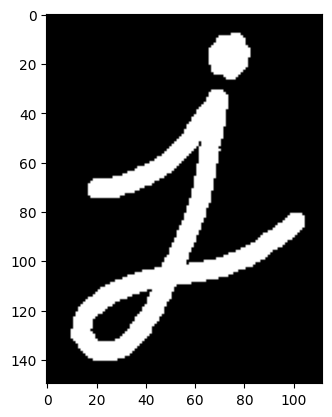

In [3]:
img_grey = cv2.imread(r'j.png')
plt.imshow(img_grey)

In [4]:
np.unique(img_grey)

array([  0, 255], dtype=uint8)

In [5]:
th = 100
im = img_grey>th

In [6]:
print(np.unique(im))

[False  True]


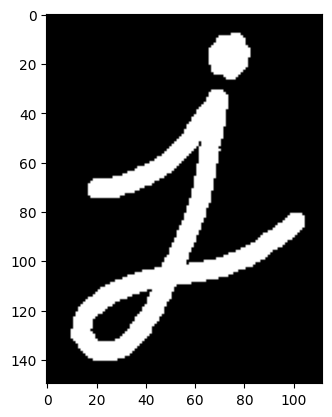

In [7]:
_, binary_img = cv2.threshold(img_grey, 127, 255, cv2.THRESH_BINARY)
plt.imshow(binary_img)


In [8]:
k_r = cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))

In [9]:
k_e = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))

In [10]:
k_c = cv2.getStructuringElement(cv2.MORPH_CROSS,(5,5))

# Erosion

In [11]:
E_r = cv2.erode(binary_img, k_r)
E_e = cv2.erode(binary_img, k_e)
E_c = cv2.erode(binary_img, k_c)

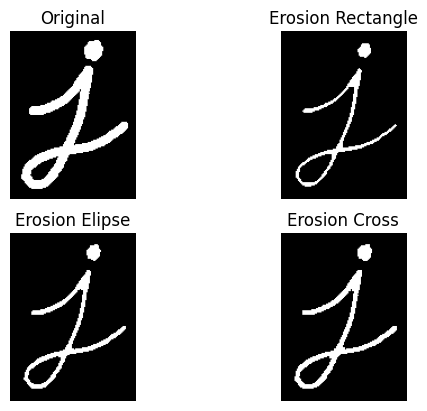

In [12]:
plt.subplot(221)
plt.imshow(binary_img)
plt.title('Original')
plt.axis('off')
plt.subplot(222)
plt.title('Erosion Rectangle')
plt.axis('off')
plt.imshow(E_r)
plt.subplot(223)
plt.title('Erosion Elipse')
plt.axis('off')
plt.imshow(E_e)
plt.subplot(224)
plt.title('Erosion Cross')
plt.axis('off')
plt.imshow(E_c)

In [13]:
print(np.sum(E_e - E_c))

510


# Dilation 

In [14]:
D_r = cv2.dilate(binary_img, k_r)
D_e = cv2.dilate(binary_img, k_e)
D_c = cv2.dilate(binary_img, k_c)

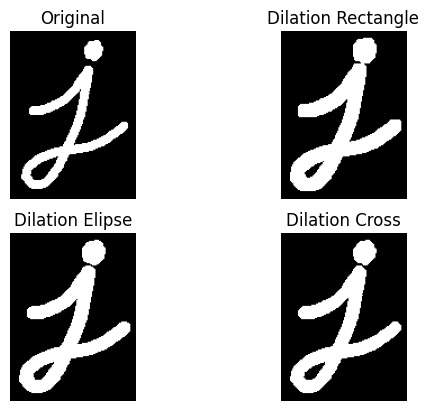

In [15]:
plt.subplot(221)
plt.imshow(binary_img)
plt.title('Original')
plt.axis('off')
plt.subplot(222)
plt.title('Dilation Rectangle')
plt.axis('off')
plt.imshow(D_r)
plt.subplot(223)
plt.title('Dilation Elipse')
plt.axis('off')
plt.imshow(D_e)
plt.subplot(224)
plt.title('Dilation Cross')
plt.axis('off')
plt.imshow(D_c)

In [16]:
binary_img.dtype

dtype('uint8')

In [17]:
im_bool = np.array(binary_img[:,:,0], dtype=np.bool)

In [18]:
noise = np.random.rand(im_bool.shape[0],im_bool.shape[1])

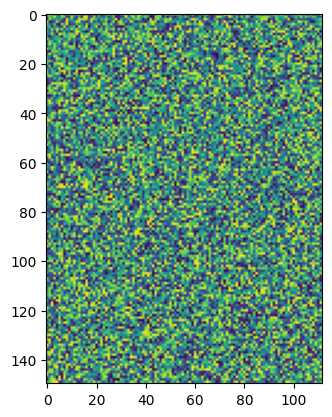

In [19]:
plt.imshow(noise)

In [20]:
noise

array([[8.62361030e-01, 8.99059031e-01, 5.94564494e-01, ...,
        9.49015222e-02, 3.19289685e-01, 8.54313610e-01],
       [3.09317156e-01, 7.87438755e-01, 6.14149251e-01, ...,
        6.49624753e-01, 2.07743411e-01, 3.26274800e-01],
       [1.28079606e-01, 8.46228603e-01, 5.98848193e-01, ...,
        4.84066791e-01, 6.54657289e-01, 7.51272945e-01],
       ...,
       [3.14074572e-01, 5.92977672e-01, 8.67914274e-01, ...,
        8.48022079e-01, 6.58650923e-01, 8.86161534e-01],
       [3.49660851e-04, 7.39756075e-01, 8.70991835e-01, ...,
        2.56559897e-01, 4.77974879e-01, 3.40829621e-01],
       [6.98922793e-01, 6.64582270e-01, 9.09702861e-01, ...,
        8.27934820e-01, 3.63498087e-01, 6.97243649e-01]], shape=(150, 112))

In [21]:
noise_binary = noise>0.99

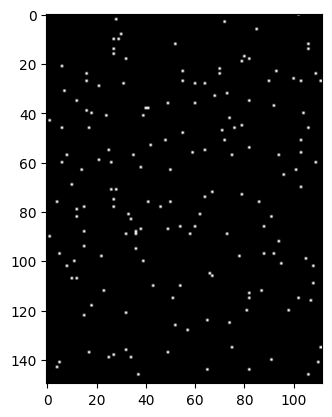

In [22]:
plt.imshow(noise_binary,cmap='grey')

In [23]:
img_noise = im_bool | noise_binary

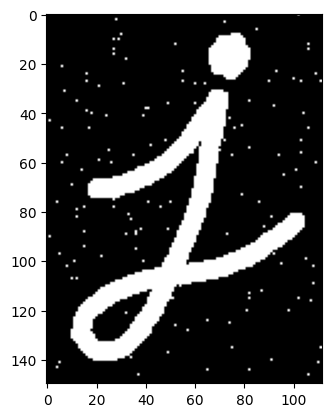

In [24]:
plt.imshow(img_noise, cmap='grey')

# Opening

In [25]:
o_r = cv2.morphologyEx(np.float32(img_noise),cv2.MORPH_OPEN,k_r)

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

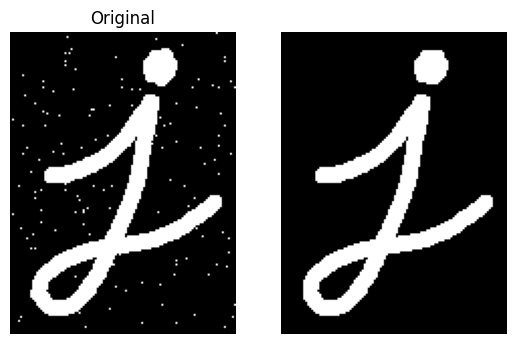

In [26]:
plt.subplot(121)
plt.imshow(img_noise,cmap='grey')
plt.title('Original')
plt.axis('off')
plt.subplot(122)
plt.imshow(o_r,cmap='grey')
plt.axis('off')

In [27]:
E_r = cv2.erode(np.float32(img_noise),k_r)

In [28]:
D_r = cv2.dilate(E_r,k_r)

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

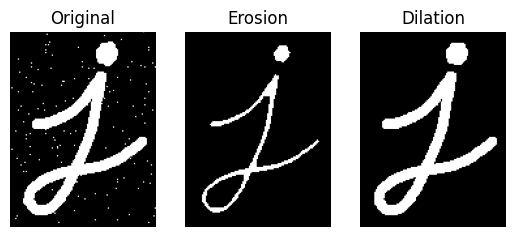

In [29]:
plt.subplot(131)
plt.imshow(img_noise,cmap='grey')
plt.title('Original')
plt.axis('off')
plt.subplot(132)
plt.imshow(E_r,cmap='grey')
plt.title('Erosion')
plt.axis('off')
plt.subplot(133)
plt.imshow(D_r,cmap='grey')
plt.title('Dilation')
plt.axis('off')

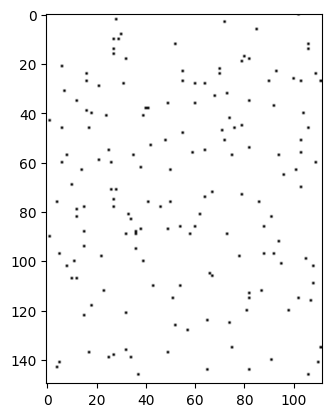

In [30]:
noise_binary = noise<0.99
plt.imshow(noise_binary, cmap='grey')

In [31]:
noise_img = im_bool & noise_binary

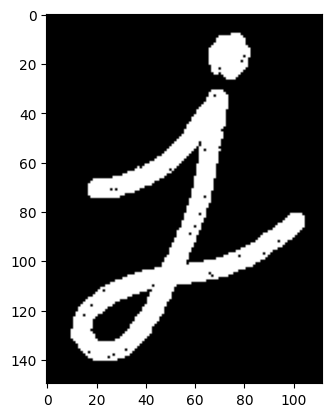

In [32]:
plt.imshow(noise_img, cmap='grey')

In [33]:
C_r = cv2.morphologyEx(np.float32(noise_img),cv2.MORPH_CLOSE,k_r)

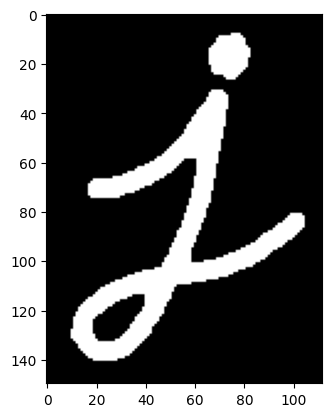

In [34]:
plt.imshow(C_r,cmap='grey')

(np.float64(-0.5), np.float64(111.5), np.float64(149.5), np.float64(-0.5))

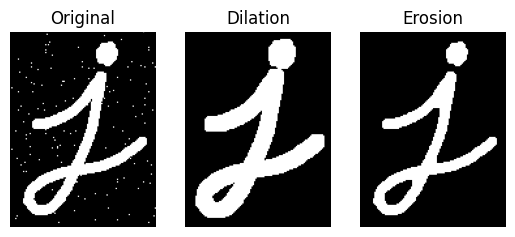

In [35]:
D_r = cv2.dilate(np.float32(noise_img),k_r)
E_r = cv2.erode(D_r,k_r)
plt.subplot(131)
plt.imshow(img_noise,cmap='grey')
plt.title('Original')
plt.axis('off')
plt.subplot(132)
plt.imshow(D_r,cmap='grey')
plt.title('Dilation')
plt.axis('off')
plt.subplot(133)
plt.imshow(E_r,cmap='grey')
plt.title('Erosion')
plt.axis('off')

# Gradient

In [41]:
Grad = cv2.morphologyEx(binary_img,cv2.MORPH_GRADIENT,k_r)

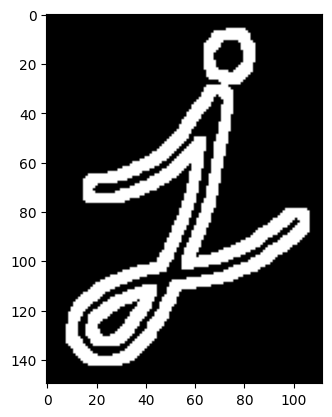

In [42]:
plt.imshow(Grad,cmap='grey')

In [43]:
D_r = cv2.dilate(binary_img, k_r)
E_r = cv2.erode(binary_img, k_r)
Gradient = D_r - E_r

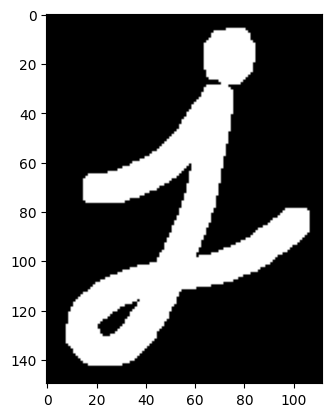

In [46]:
plt.imshow(D_r-E_r, cmap='grey')

# Top Hat


In [55]:
top_hat = cv2.morphologyEx(E_r,cv2.MORPH_TOPHAT,k_r)

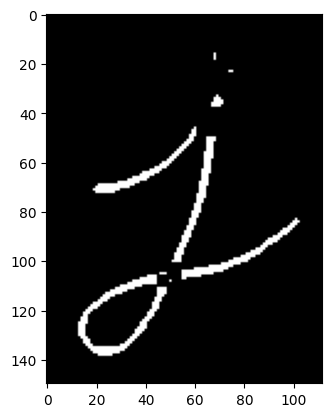

In [56]:
plt.imshow(top_hat, cmap='grey')

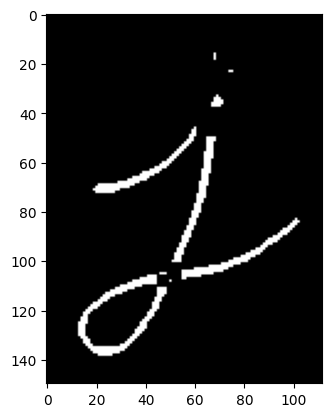

In [59]:
o_r = cv2.morphologyEx(E_r[:,:,0],cv2.MORPH_OPEN,k_r)
plt.imshow(E_r[:,:,0]-o_r, cmap='grey')

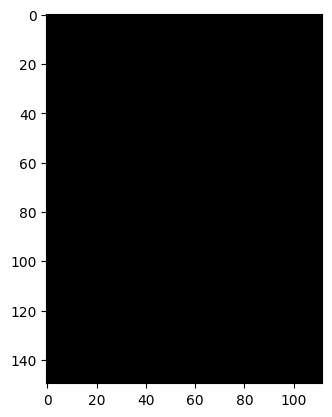